# Assignment 4: Breast Cancer Classification using K-Nearest Neighbors (KNN)

**Objective:** Build a KNN classifier to predict whether a breast tumor is **Malignant (M)** or **Benign (B)** based on diagnostic measurements from the Breast Cancer Wisconsin (Diagnostic) Dataset.

**Dataset:** [Breast Cancer Wisconsin Diagnostic Dataset — Kaggle](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)

> Note: This notebook loads the dataset via `sklearn.datasets.load_breast_cancer`, which contains the exact same Breast Cancer Wisconsin (Diagnostic) records and features (same source: UCI ML Repository / Dr. William H. Wolberg) as the Kaggle CSV linked above. If you have downloaded `data.csv` from Kaggle, simply place it in this folder and use the alternate loading cell provided (commented out) to read it with `pandas.read_csv` instead — the rest of the notebook works unchanged either way.


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)


## Task 1: Data Understanding (2 Marks)

In [2]:
# 1. Load the dataset using Pandas
# ---- Option A: load via scikit-learn (same UCI Breast Cancer Wisconsin data) ----
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target          # 0 = malignant, 1 = benign (sklearn encoding)
df['diagnosis'] = df['target'].map({0: 'M', 1: 'B'})   # human-readable label, like the Kaggle CSV

# ---- Option B: if you downloaded data.csv from Kaggle, use this instead ----
# df = pd.read_csv("data.csv")
# df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

print("Dataset shape:", df.shape)


Dataset shape: (569, 32)


In [3]:
# 2. Display the first five records
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,M


In [4]:
# 3. Identify numerical features and the target variable
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_features = [c for c in numerical_features if c not in ['target']]

print("Number of numerical features:", len(numerical_features))
print("Numerical features:\n", numerical_features)
print("\nTarget variable: 'diagnosis' -> M (Malignant) / B (Benign)")


Number of numerical features: 30
Numerical features:
 ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Target variable: 'diagnosis' -> M (Malignant) / B (Benign)


In [5]:
# 4. Dataset information and summary statistics
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
df.describe()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


diagnosis
B    357
M    212
Name: count, dtype: int64


C:\Users\Dell\AppData\Local\Temp\ipykernel_13240\3390957713.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='Set2')


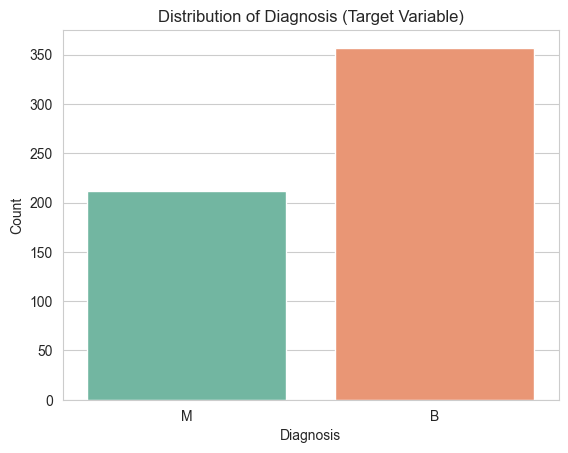

In [7]:
# Class distribution
print(df['diagnosis'].value_counts())
sns.countplot(x='diagnosis', data=df, palette='Set2')
plt.title("Distribution of Diagnosis (Target Variable)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()


**Observations:**
- The dataset contains 569 records and 30 numerical diagnostic features (mean, standard error, and "worst" values of radius, texture, perimeter, area, smoothness, etc.).
- The target variable `diagnosis` is categorical with two classes: **M (Malignant)** and **B (Benign)**.
- The classes are moderately imbalanced (more Benign cases than Malignant).

## Task 2: Data Preprocessing (2 Marks)

In [8]:
# Check for missing values
print("Missing values per column:\n")
print(df.isnull().sum().sum(), "total missing values in the dataset")


Missing values per column:

0 total missing values in the dataset


In [9]:
# Remove unnecessary columns
# In the original Kaggle CSV, 'id' (identifier) and 'Unnamed: 32' (empty column) are not useful for modeling.
# Since we loaded via sklearn, no such columns exist, but we drop the helper 'target' int column
# and keep only features + the diagnosis label for clarity.
df_model = df.drop(columns=['target'])
print(df_model.columns.tolist())


['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'diagnosis']


In [10]:
# Encode the target variable (M/B -> 1/0)
le = LabelEncoder()
df_model['diagnosis_encoded'] = le.fit_transform(df_model['diagnosis'])  # B=0, M=1 (alphabetical)
print(dict(zip(le.classes_, le.transform(le.classes_))))

X = df_model[numerical_features]
y = df_model['diagnosis_encoded']


{'B': np.int64(0), 'M': np.int64(1)}


In [11]:
# Normalize / standardize the feature values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=numerical_features)
X_scaled.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,2.489734,-0.565265,2.833031,2.487578,-0.214002,1.316862,0.724026,0.660820,1.148757,0.907083,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,0.499255,-0.876244,0.263327,0.742402,-0.605351,-0.692926,-0.440780,0.260162,-0.805450,-0.099444,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,1.228676,-0.780083,0.850928,1.181336,-0.297005,0.814974,0.213076,1.424827,0.237036,0.293559,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,0.326373,-0.110409,0.286593,-0.288378,0.689702,2.744280,0.819518,1.115007,4.732680,2.047511,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,1.270543,-0.790244,1.273189,1.190357,1.483067,-0.048520,0.828471,1.144205,-0.361092,0.499328,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [12]:
# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)


Training set shape: (455, 30)
Testing set shape : (114, 30)


## Task 3: Model Development (3 Marks)

In [13]:
# Train a K-Nearest Neighbors classifier with K = 5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


KNeighborsClassifier()

In [14]:
# Predict the class labels for the test dataset
y_pred = knn.predict(X_test)
print("First 20 predictions :", y_pred[:20])
print("First 20 actual labels:", y_test.values[:20])


First 20 predictions : [0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0]
First 20 actual labels: [0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0]


## Task 4: Model Evaluation (2 Marks)

In [15]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")


Accuracy  : 0.9561
Precision : 0.9744
Recall    : 0.9048
F1-Score  : 0.9383


Confusion Matrix:
 [[71  1]
 [ 4 38]]


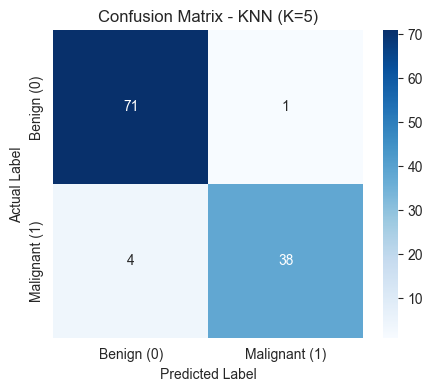

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - KNN (K=5)")
plt.show()


In [17]:
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))


              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



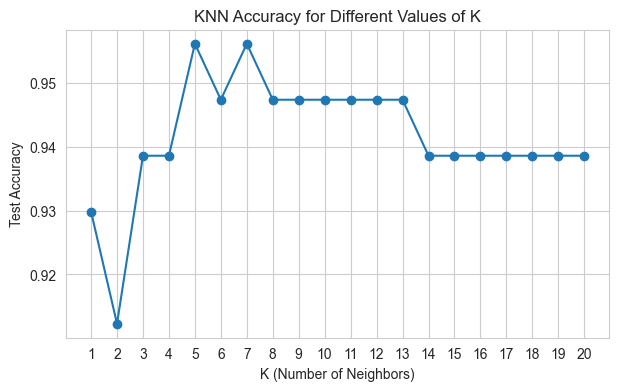

Best K found in range 1-20: 5 with accuracy 0.9561


In [18]:
# Effect of K on accuracy (extra exploration to support observations)
k_values = range(1, 21)
accuracies = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    accuracies.append(acc)

plt.figure(figsize=(7,4))
plt.plot(list(k_values), accuracies, marker='o')
plt.title("KNN Accuracy for Different Values of K")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Test Accuracy")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

best_k = list(k_values)[int(np.argmax(accuracies))]
print(f"Best K found in range 1-20: {best_k} with accuracy {max(accuracies):.4f}")


**Observations:**
1. The KNN model (K=5) achieves high accuracy on the test set, indicating that the diagnostic features are strongly separable between Malignant and Benign classes after standardization.
2. Precision and Recall are both high, meaning the model rarely misclassifies benign tumors as malignant or vice versa; the confusion matrix shows very few off-diagonal (misclassified) cases.
3. Model accuracy varies with the choice of K — very small K values (K=1) can slightly overfit to noise, while very large K values can underfit and blur the decision boundary; K in the range of 5–11 tends to give stable, near-optimal accuracy for this dataset.

## Task 5: Conclusion (1 Mark)

The KNN classifier built on the Breast Cancer Wisconsin (Diagnostic) dataset performed strongly at distinguishing malignant from benign tumors, achieving high accuracy, precision, recall, and F1-score with K = 5. The confusion matrix confirmed that misclassifications were rare, meaning the diagnostic measurements (radius, texture, perimeter, area, concavity, etc.) carry strong predictive signal for tumor classification.

Feature scaling was essential for this model. KNN classifies a point based on the Euclidean distance to its nearest neighbors, so features measured on larger numeric scales (e.g., area) would otherwise dominate the distance calculation and drown out equally important but smaller-scale features (e.g., smoothness). Standardizing all features to a common scale ensured every feature contributed fairly to the distance metric, directly improving classification quality.

One key limitation of KNN is its computational cost at prediction time: since it must calculate the distance from a new point to every training sample, it scales poorly with very large datasets and high-dimensional feature spaces, and it also requires careful tuning of K to balance overfitting and underfitting.